# Exploratory 3 — Desc. Stats

Ditulis oleh: Atha Bintang Wahyu M.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

DATA_BERSIH = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/DATA_BERSIH")

YEARS = [2011, 2014, 2018, 2021, 2024]
adm4_files = {y: DATA_BERSIH / f"adm4_podes_{y}_with_iup_flag.gpkg" for y in YEARS}
adm4_pca_files = {y: DATA_BERSIH / f"adm4_podes_{y}_with_iup_flag_pca.gpkg" for y in YEARS}

gdf_by_year = {}
gdf_pca_by_year = {}
for y in YEARS:
    p = adm4_files.get(y)
    if p and p.exists():
        gdf_by_year[y] = gpd.read_file(p)
    pp = adm4_pca_files.get(y)
    if pp and pp.exists():
        gdf_pca_by_year[y] = gpd.read_file(pp)

print("Tahun yang terbaca (dengan IUP):", list(gdf_by_year.keys()))
print("Tahun yang terbaca (dengan PCA):", list(gdf_pca_by_year.keys()))

panel_pca_only = None
panel_pca_with_smelter = None
panel_smelter_reg1 = None
panel_smelter_reg2 = None
for name, path in [
    ("panel_PCA_only", DATA_BERSIH / "panel_PCA_only.csv"),
    ("panel_PCA_with_smelter", DATA_BERSIH / "panel_PCA_with_smelter.csv"),
    ("panel_PCA_with_smelter_reg1", DATA_BERSIH / "panel_PCA_with_smelter_reg1.csv"),
    ("panel_PCA_with_smelter_reg2", DATA_BERSIH / "panel_PCA_with_smelter_reg2.csv"),
]:
    p = path
    if p.exists():
        df = pd.read_csv(p)
        if name == "panel_PCA_only":
            panel_pca_only = df
        elif name == "panel_PCA_with_smelter":
            panel_pca_with_smelter = df
        elif name == "panel_PCA_with_smelter_reg1":
            panel_smelter_reg1 = df
        else:
            panel_smelter_reg2 = df
        print(f"Panel {name}: {len(df)} rows")
    else:
        print(f"Panel {name}: file tidak ditemukan — jalankan cleaning2.")

panel_smelter = panel_pca_with_smelter

Tahun yang terbaca (dengan IUP): [2011, 2014, 2018, 2021, 2024]
Tahun yang terbaca (dengan PCA): [2011, 2014, 2018, 2021, 2024]
Panel panel_PCA_only: 411510 rows
Panel panel_PCA_with_smelter: 411510 rows
Panel panel_PCA_with_smelter_reg1: 411510 rows
Panel panel_PCA_with_smelter_reg2: 411510 rows


**Panel data (CSV):** For panel analysis use the loaded DataFrames:
- `panel_pca_only` — PCA + has_iup only (no smelter).
- `panel_pca_with_smelter` — PCA + has_iup + smelter_reg1 & smelter_reg2 (default for smelter stats/maps, stored in `panel_smelter`).
- `panel_smelter_reg1` — Regimen 1 (campuran) only.
- `panel_smelter_reg2` — Regimen 2 (full kecamatan) only.

Maps still use per-year gpkg (`gdf_by_year`, `gdf_pca_by_year`) for geometry.

## 1. Stats Desc Tables — Desa with IUP

In [2]:
# Desa dengan IUP by year
iup_col = "has_iup"  # 0/1 in DATA_BERSIH
rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    if iup_col not in g.columns:
        continue
    n_total = len(g)
    n_iup = g[iup_col].fillna(0).astype(int).sum()
    pct = 100 * n_iup / n_total if n_total else 0
    rows.append({"year": y, "n_desa": n_total, "desa_dengan_IUP": n_iup, "pct_desa_IUP": round(pct, 2)})

df_desa_iup_by_year = pd.DataFrame(rows)
df_desa_iup_by_year

,year,n_desa,desa_dengan_IUP,pct_desa_IUP
0,2011,83862,880,1.05
1,2014,81912,4846,5.92
2,2018,81912,4902,5.98
3,2021,81912,4830,5.90
4,2024,81912,4813,5.88


In [3]:
# one df per year
for y in [2014, 2024]:
    if y not in gdf_by_year:
        continue
    g = gdf_by_year[y]
    if "has_iup" not in g.columns:
        continue
    tab = pd.DataFrame({
        "has_iup": [0, 1],
        "label": ["Tidak ada IUP", "Desa dengan IUP"],
        "n_desa": [ (g["has_iup"] == 0).sum(), (g["has_iup"] == 1).sum() ],
    })
    tab["pct"] = (100 * tab["n_desa"] / tab["n_desa"].sum()).round(2)
    print(f"--- Tahun {y} ---")
    display(tab)
    print()

--- Tahun 2014 ---


,has_iup,label,n_desa,pct
0,0,Tidak ada IUP,77066,94.08
1,1,Desa dengan IUP,4846,5.92



--- Tahun 2024 ---


,has_iup,label,n_desa,pct
0,0,Tidak ada IUP,77099,94.12
1,1,Desa dengan IUP,4813,5.88


## 2. IUP peta (2014 & 2024)


In [4]:
# Helper
def get_admin_boundaries(gdf, level="ADM2"):
    for col in ["ADM2_PCODE", "ADM2_EN", "NAMA_KAB", "ADM3_PCODE"]:
        if col in gdf.columns:
            by = "ADM2_PCODE" if "ADM2_PCODE" in gdf.columns else ("NAMA_KAB" if "NAMA_KAB" in gdf.columns else "ADM3_PCODE")
            break
    else:
        by = gdf.columns[1]  # fallback
    if "ADM2_PCODE" in gdf.columns:
        admin = gdf.dissolve(by="ADM2_PCODE", aggfunc="first").reset_index()
    elif "NAMA_KAB" in gdf.columns:
        admin = gdf.dissolve(by="NAMA_KAB", aggfunc="first").reset_index()
    else:
        admin = gdf.dissolve(by=gdf.columns[1], aggfunc="first").reset_index()
    return gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=gdf.crs)

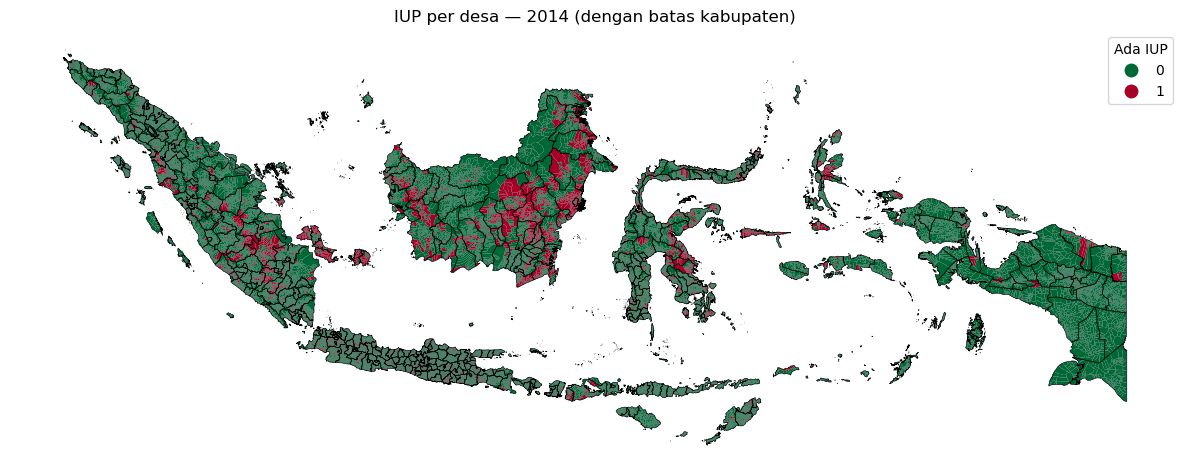

In [5]:
# with/without IUP + admin boundaries
year = 2014
if year in gdf_by_year:
    g = gdf_by_year[year].copy()
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column="has_iup", categorical=True, legend=True, ax=ax, cmap="RdYlGn_r", linewidth=0.05, edgecolor="gray", legend_kwds={"title": "Ada IUP"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"IUP per desa — {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Tidak ada data untuk tahun {year}")

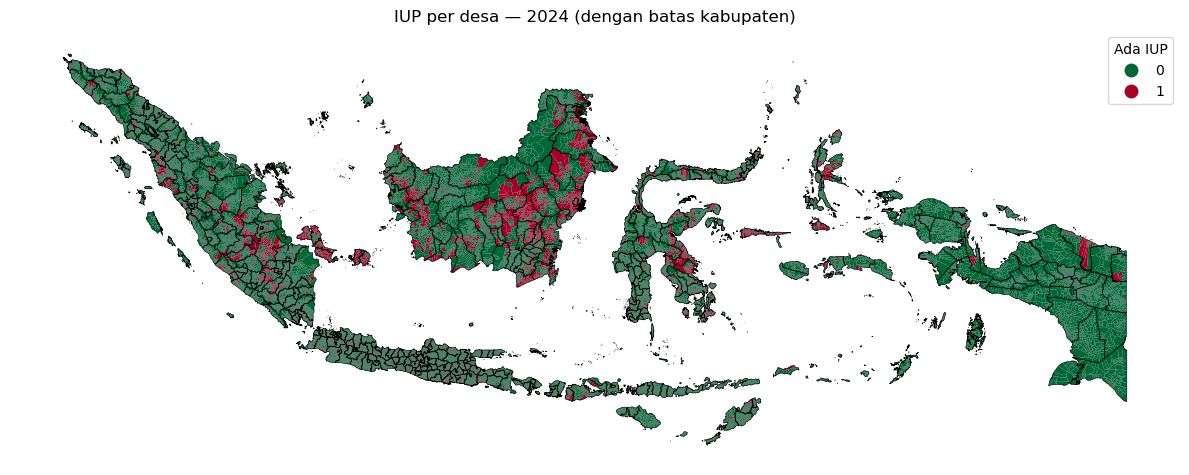

In [6]:
year = 2024
if year in gdf_by_year:
    g = gdf_by_year[year].copy()
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column="has_iup", categorical=True, legend=True, ax=ax, cmap="RdYlGn_r", linewidth=0.05, edgecolor="gray", legend_kwds={"title": "Ada IUP"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"IUP per desa — {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print(f"Tidak ada data untuk tahun {year}")

In [7]:
# share of villages with IUP by province
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    prov_col = "NAMA_PROV" if "NAMA_PROV" in g.columns else "ADM1_EN"
    if prov_col not in g.columns:
        continue
    agg = g.groupby(prov_col).agg(n_desa=("has_iup", "count"), n_iup=("has_iup", "sum")).reset_index()
    agg["pct_iup"] = (100 * agg["n_iup"] / agg["n_desa"]).round(2)
    agg = agg.sort_values("pct_iup", ascending=False)
    print(f"Tahun {year} — % desa dengan IUP per provinsi (10 teratas):")
    display(agg.head(10))
    print()

Tahun 2014 — % desa dengan IUP per provinsi (10 teratas):


,ADM1_EN,n_desa,n_iup,pct_iup
16,Kepulauan Bangka Belitung,391,206,52.69
14,Kalimantan Timur,1032,354,34.30
13,Kalimantan Tengah,1574,359,22.81
12,Kalimantan Selatan,2008,361,17.98
15,Kalimantan Utara,482,67,13.90
4,Daerah Istimewa Yogyakarta,438,59,13.47
20,Maluku Utara,1230,164,13.33
32,Sumatera Selatan,3264,402,12.32
11,Kalimantan Barat,2132,243,11.40
28,Sulawesi Tengah,2025,222,10.96



Tahun 2024 — % desa dengan IUP per provinsi (10 teratas):


,NAMA_PROV,n_desa,n_iup,pct_iup
16,KEPULAUAN BANGKA BELITUNG,391,211,53.96
14,KALIMANTAN TIMUR,1012,344,33.99
13,KALIMANTAN TENGAH,1570,363,23.12
12,KALIMANTAN SELATAN,1962,345,17.58
15,KALIMANTAN UTARA,456,65,14.25
4,DI YOGYAKARTA,438,60,13.70
20,MALUKU UTARA,1176,159,13.52
11,KALIMANTAN BARAT,2132,260,12.20
32,SUMATERA SELATAN,3206,385,12.01
29,SULAWESI TENGGARA,2271,256,11.27


### IUP area (ha) 

Desa dengan IUP saja; skala log(1 + area_hectares_iup). 

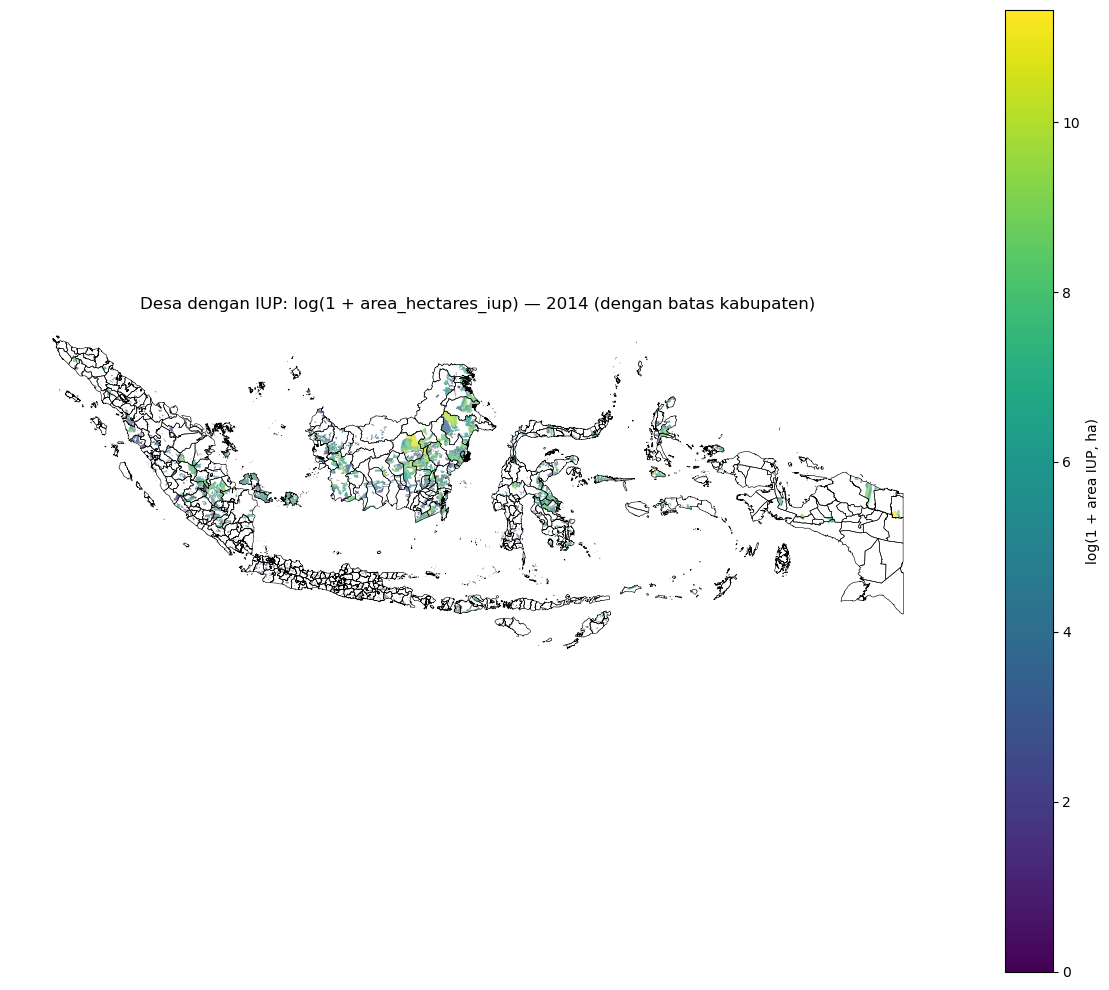

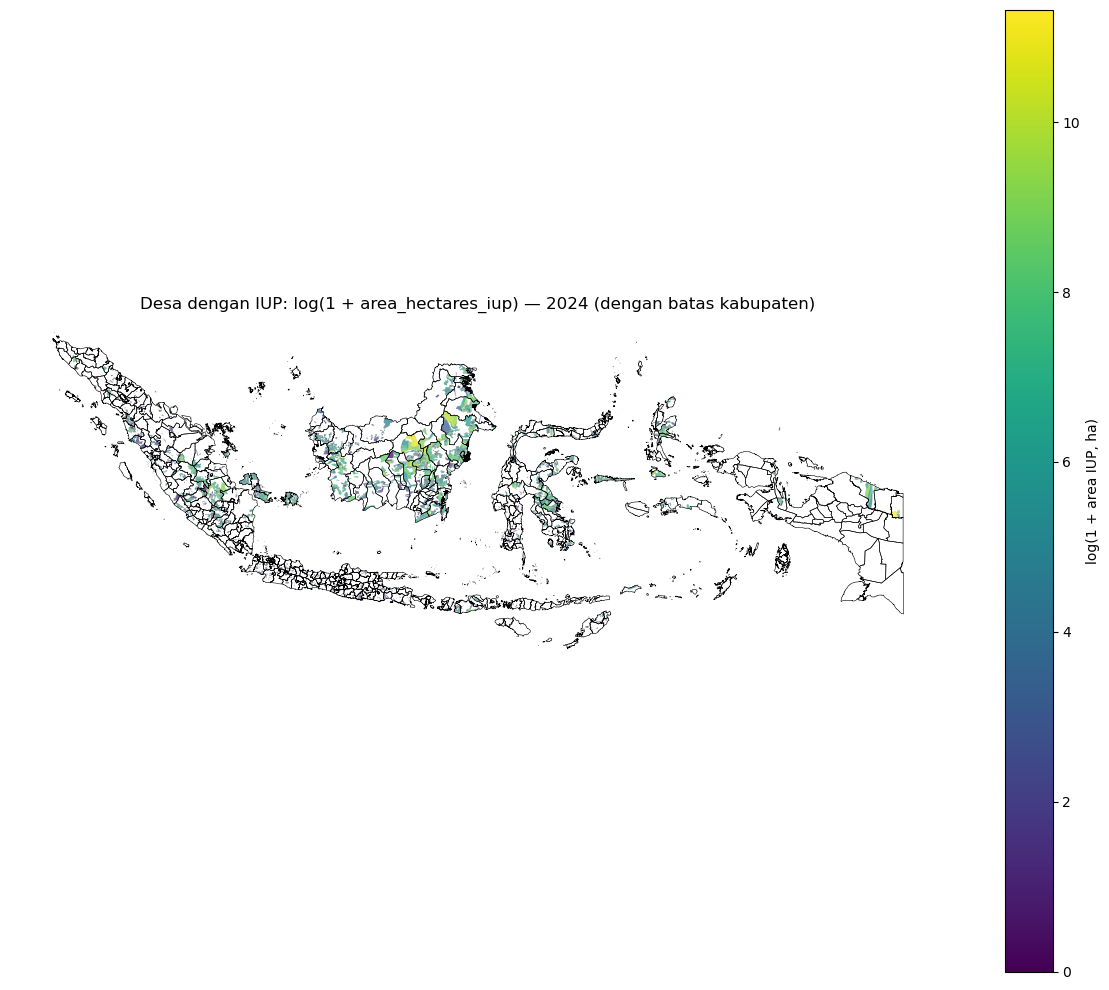

In [8]:
# IUP area (ha) map — villages with IUP only, log scale; with admin boundaries (no contextily)
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year].copy()
    if "area_hectares_iup" not in g.columns:
        print(f"Tahun {year}: kolom area_hectares_iup tidak ada; skip.")
        continue
    with_iup = g[g["has_iup"] == 1].copy()
    if len(with_iup) == 0:
        print(f"Tahun {year}: tidak ada desa dengan IUP.")
        continue
    with_iup["area_log"] = np.log1p(with_iup["area_hectares_iup"].fillna(0))
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    if with_iup.crs is None:
        with_iup.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    with_iup.plot(column="area_log", legend=True, ax=ax, cmap="viridis", linewidth=0.08, edgecolor="gray",
                  alpha=0.75, legend_kwds={"label": "log(1 + area IUP, ha)"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Desa dengan IUP: log(1 + area_hectares_iup) — {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 3. Peta Welfare Outcome (PCA) — 2014 dan 2024

- **Equity (Paper 1)**: first PC dari variabel ekuitas → `pca_P1_pc1`
- **Health (Paper 2)**: first PC dari variabel infrastruktur kesehatan → `pca_P2_pc1`

Maps for 2014 and 2024 dengan batas administrasi.

In [9]:
# PCA diagnostic
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year]
    for col in ["pca_P1_pc1", "pca_P2_pc1"]:
        if col not in g.columns:
            continue
        v = g[col].dropna()
        n_valid = len(v)
        n_total = len(g)
        pct = 100 * n_valid / n_total if n_total else 0
        print(f"{year} {col}: valid={n_valid}, total={n_total}, cakupan={pct:.1f}%")
        if len(v) > 0:
            print(f"  min={v.min():.3f}, max={v.max():.3f}, mean={v.mean():.3f}, std={v.std():.3f}")
    print()

2014 pca_P1_pc1: valid=79681, total=81912, cakupan=97.3%
  min=-13.769, max=51.677, mean=-0.000, std=3.971
2014 pca_P2_pc1: valid=79681, total=81912, cakupan=97.3%
  min=-11.347, max=15.110, mean=-0.000, std=3.603

2024 pca_P1_pc1: valid=77123, total=81912, cakupan=94.2%
  min=-13.501, max=42.335, mean=-0.000, std=3.722
2024 pca_P2_pc1: valid=77123, total=81912, cakupan=94.2%
  min=-15.329, max=14.810, mean=-0.000, std=3.265



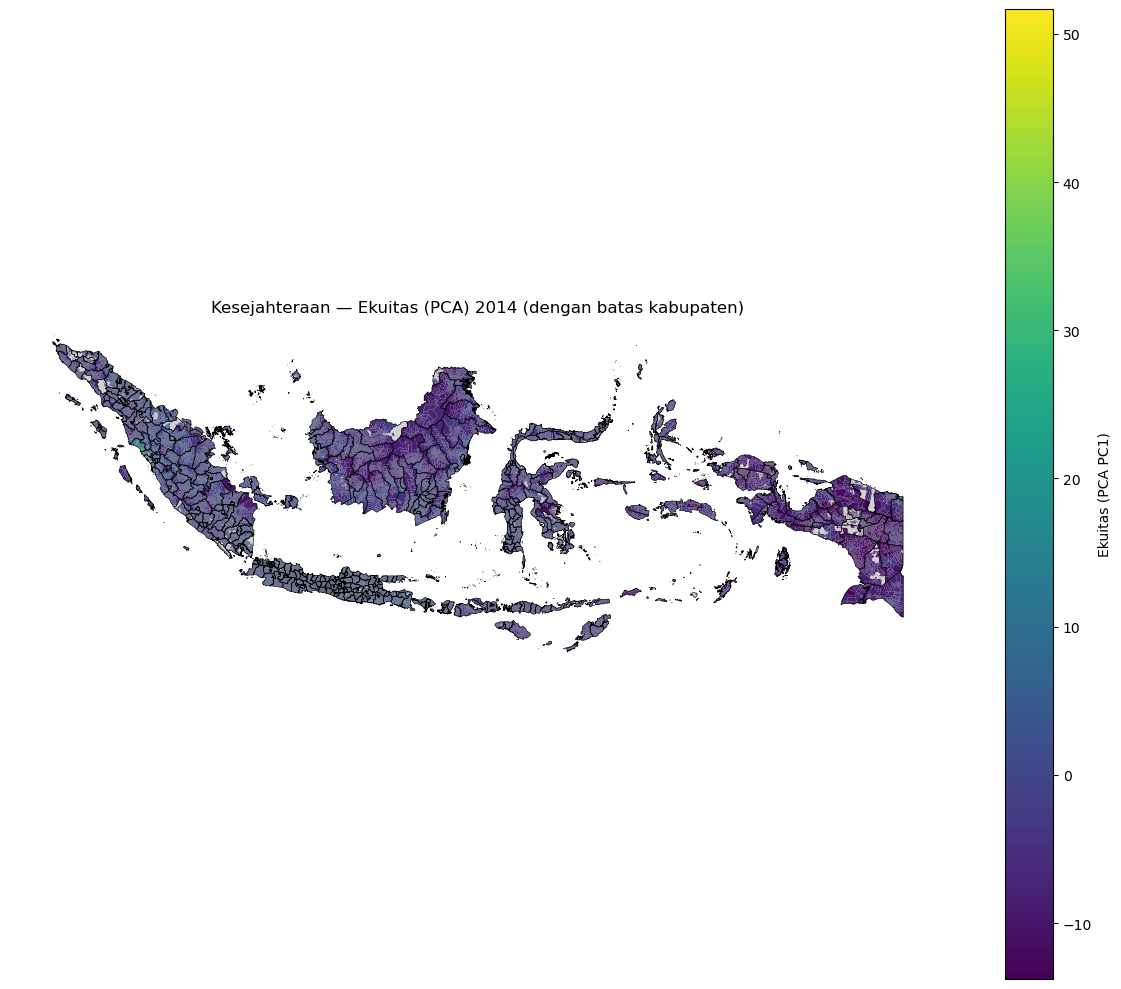

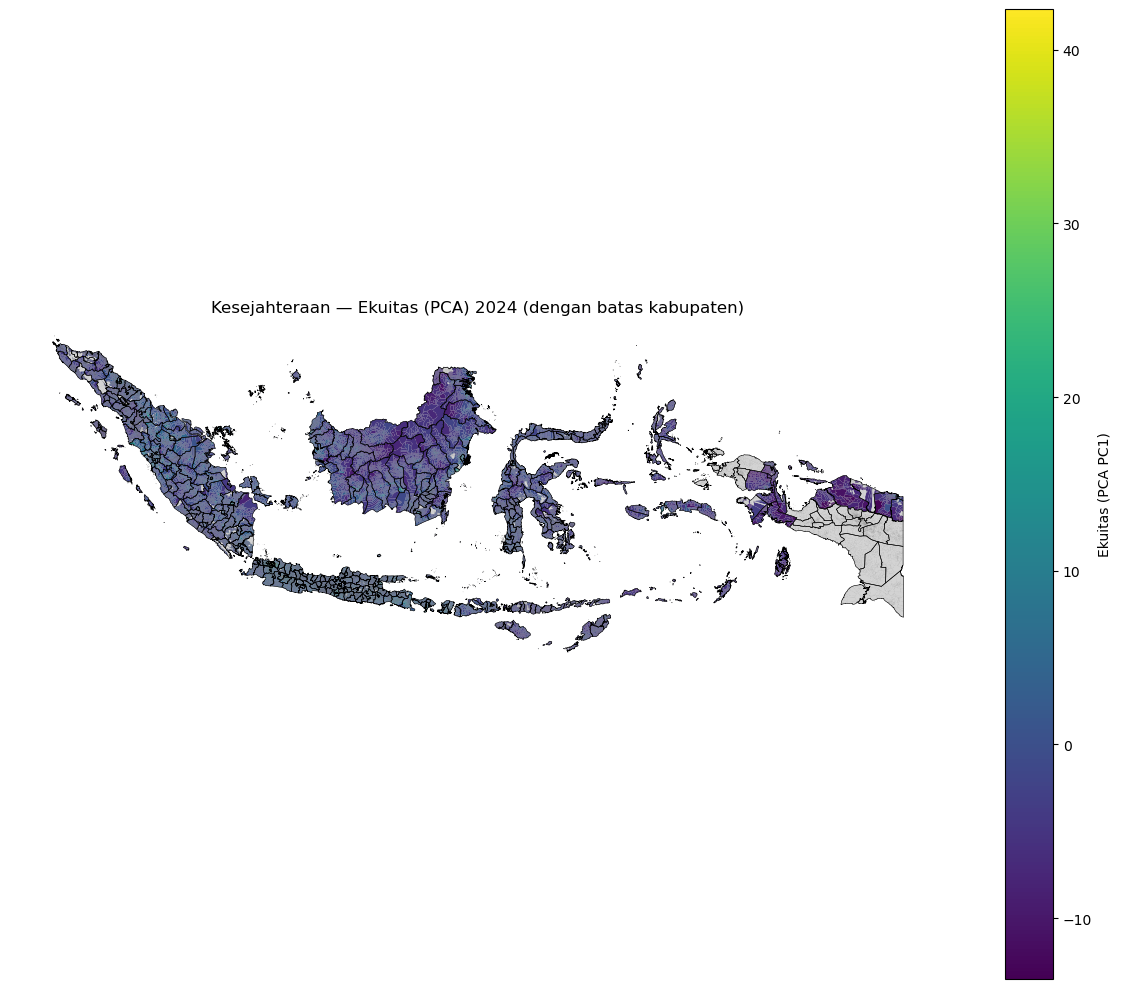

In [10]:
# PCA Equity (P1) — 2014 and 2024 (NaN/missing shown in light gray)
col_p1 = "pca_P1_pc1"
for year in [2014, 2024]:
    if year not in gdf_pca_by_year or col_p1 not in gdf_pca_by_year[year].columns:
        print(f"Lewati {year}: tidak ada PCA P1")
        continue
    g = gdf_pca_by_year[year].copy()
    if not hasattr(g, "geometry") or g.geometry is None:
        print(f"Lewati {year}: tidak ada geometri (gunakan file gpkg untuk peta)")
        continue
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column=col_p1, legend=True, ax=ax, cmap="viridis", linewidth=0.05, edgecolor="gray",
           legend_kwds={"label": "Ekuitas (PCA PC1)"},
           missing_kwds={"color": "lightgray", "label": "Tidak ada data"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Kesejahteraan — Ekuitas (PCA) {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

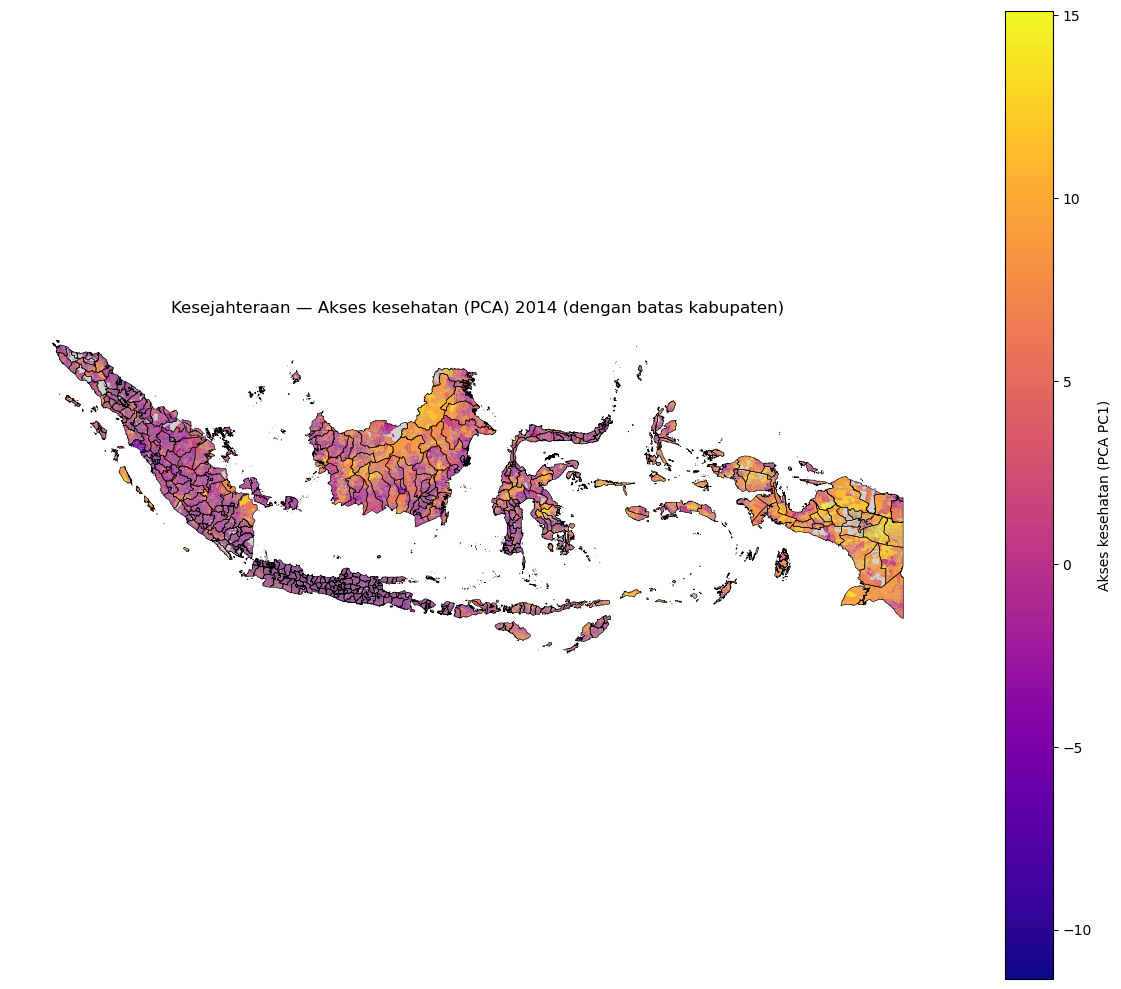

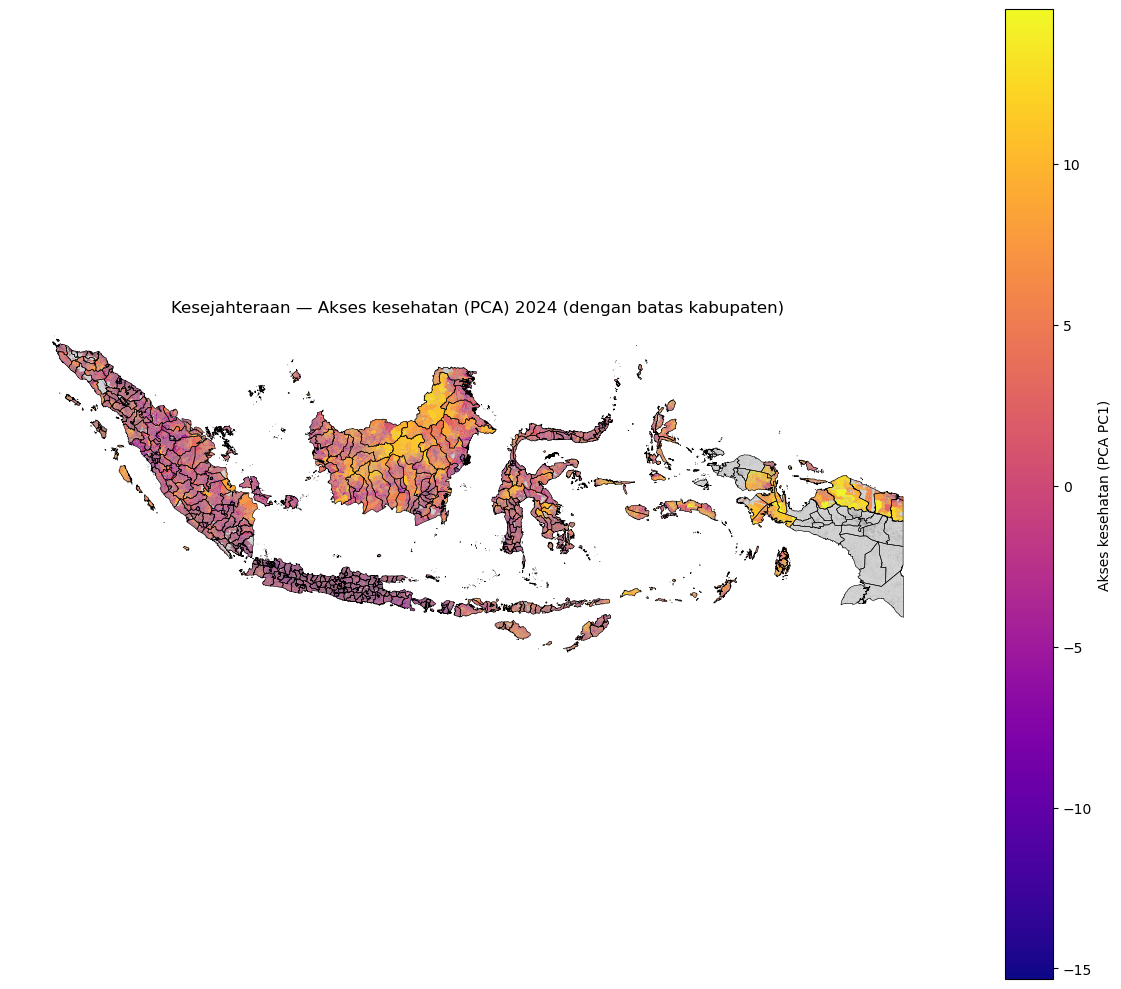

In [11]:
# PCA Health (P2) — 2014 and 2024 (NaN/missing shown in light gray)
col_p2 = "pca_P2_pc1"
for year in [2014, 2024]:
    if year not in gdf_pca_by_year or col_p2 not in gdf_pca_by_year[year].columns:
        print(f"Lewati {year}: tidak ada PCA P2")
        continue
    g = gdf_pca_by_year[year].copy()
    if not hasattr(g, "geometry") or g.geometry is None:
        print(f"Lewati {year}: tidak ada geometri (gunakan file gpkg untuk peta)")
        continue
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    g.plot(column=col_p2, legend=True, ax=ax, cmap="plasma", linewidth=0.05, edgecolor="gray",
           legend_kwds={"label": "Akses kesehatan (PCA PC1)"},
           missing_kwds={"color": "lightgray", "label": "Tidak ada data"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Kesejahteraan — Akses kesehatan (PCA) {year} (dengan batas kabupaten)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 4. Tabel dan analisis tambahan

Descriptive stats untuk skor PCA per tahun; welfare (Equity & Health) IUP vs non-IUP; ringkasan tingkat provinsi; plus tabel dan grafik tambahan untuk nuansa analisis.

In [12]:
# Table: PCA (Equity & Health) descriptive stats by year
rows = []
for y in sorted(gdf_pca_by_year.keys()):
    g = gdf_pca_by_year[y]
    r = {"year": y}
    for col in ["pca_P1_pc1", "pca_P2_pc1"]:
        if col not in g.columns:
            continue
        v = g[col].dropna()
        r[f"{col}_mean"] = round(v.mean(), 4)
        r[f"{col}_std"] = round(v.std(), 4)
        r[f"{col}_n"] = len(v)
    rows.append(r)
df_pca_stats = pd.DataFrame(rows)
df_pca_stats

,year,pca_P1_pc1_mean,pca_P1_pc1_std,pca_P1_pc1_n,pca_P2_pc1_mean,pca_P2_pc1_std,pca_P2_pc1_n
0,2011,-0.0,3.8721,18731,-0.0,2.7081,18731
1,2014,-0.0,3.9713,79681,-0.0,3.6026,79681
2,2018,0.0,4.4588,80822,-0.0,3.5637,80822
3,2021,-0.0,3.7208,80350,-0.0,4.6464,80350
4,2024,-0.0,3.7219,77123,-0.0,3.2646,77123


In [13]:
# Table: Mean welfare (PCA) by IUP status — 2014 and 2024
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year]
    if "has_iup" not in g.columns or "pca_P1_pc1" not in g.columns:
        continue
    cols = ["pca_P1_pc1", "pca_P2_pc1"]
    cols = [c for c in cols if c in g.columns]
    tab = g.groupby("has_iup")[cols].agg(["mean", "std", "count"]).round(4)
    tab.index = ["No IUP", "Has IUP"]
    print(f"Tahun {year} — Rata-rata (std, jumlah) PCA menurut status IUP:")
    display(tab)
    print()

Tahun 2014 — Rata-rata (std, jumlah) PCA menurut status IUP:


pca_P1_pc1                pca_P2_pc1               
              mean     std  count       mean     std  count
No IUP      0.0447  4.0022  74835    -0.0309  3.6224  74835
Has IUP    -0.6903  3.3850   4846     0.4778  3.2458   4846


Tahun 2024 — Rata-rata (std, jumlah) PCA menurut status IUP:


pca_P1_pc1                pca_P2_pc1               
              mean     std  count       mean     std  count
No IUP      0.0363  3.7576  72310    -0.0466  3.2641  72310
Has IUP    -0.5448  3.0861   4813     0.7000  3.1914   4813

In [14]:
# Table: Desa dengan IUP by province — all years (pivot)
rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    if "has_iup" not in g.columns:
        continue
    prov_col = "NAMA_PROV" if "NAMA_PROV" in g.columns else ("ADM1_EN" if "ADM1_EN" in g.columns else None)
    if prov_col is None:
        continue
    agg = g.groupby(prov_col).agg(n_desa=("has_iup", "count"), n_iup=("has_iup", "sum")).reset_index()
    agg = agg.rename(columns={prov_col: "NAMA_PROV"})  # standardize for concat/pivot
    agg["year"] = y
    rows.append(agg)
if rows:
    df_prov = pd.concat(rows, ignore_index=True)
    df_prov["pct_iup"] = (100 * df_prov["n_iup"] / df_prov["n_desa"]).round(2)
    pivot_n = df_prov.pivot(index="NAMA_PROV", columns="year", values="n_iup").fillna(0).astype(int)
    pivot_pct = df_prov.pivot(index="NAMA_PROV", columns="year", values="pct_iup")
    print("Jumlah desa dengan IUP per provinsi dan tahun:")
    display(pivot_n)
    print("\n% desa dengan IUP per provinsi dan tahun:")
    display(pivot_pct.round(2))

Jumlah desa dengan IUP per provinsi dan tahun:


year,2011,2014,2018,2021,2024
NAMA_PROV,,,,,
ACEH,0,0,0,0,61
Aceh,0,61,61,61,0
BALI,0,0,0,0,1
BANTEN,15,0,0,0,83
BENGKULU,6,0,0,0,116
...,...,...,...,...,...
Sulawesi Tenggara,0,219,254,246,0
Sulawesi Utara,0,120,121,121,0
Sumatera Barat,0,86,87,87,0



% desa dengan IUP per provinsi dan tahun:


year,2011,2014,2018,2021,2024
NAMA_PROV,,,,,
ACEH,NaN,NaN,NaN,NaN,0.94
Aceh,NaN,0.93,0.93,0.93,NaN
BALI,NaN,NaN,NaN,NaN,0.14
BANTEN,2.68,NaN,NaN,NaN,5.35
BENGKULU,40.00,NaN,NaN,NaN,7.72
...,...,...,...,...,...
Sulawesi Tenggara,NaN,9.36,10.85,10.51,NaN
Sulawesi Utara,NaN,6.53,6.58,6.58,NaN
Sumatera Barat,NaN,7.38,7.47,7.47,NaN


In [15]:
# Table: IUP intensity (among desa with IUP) — n_wiup, area_hectares_iup, pct_iup_coverage by year
iup_intensity_cols = ["n_wiup", "area_hectares_iup", "pct_iup_coverage"]
rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    with_iup = g[g["has_iup"] == 1] if "has_iup" in g.columns else g
    if len(with_iup) == 0:
        continue
    r = {"year": y, "n_desa_with_iup": len(with_iup)}
    for c in iup_intensity_cols:
        if c in with_iup.columns:
            r[f"{c}_mean"] = round(with_iup[c].mean(), 2)
            r[f"{c}_median"] = round(with_iup[c].median(), 2)
    rows.append(r)
pd.DataFrame(rows)

,year,n_desa_with_iup,n_wiup_mean,n_wiup_median,area_hectares_iup_mean,area_hectares_iup_median,pct_iup_coverage_mean,pct_iup_coverage_median
0,2011,880,4.02,2.0,697.91,25.84,11.64,2.38
1,2014,4846,2.94,2.0,579.52,44.62,9.77,2.64
2,2018,4902,2.94,2.0,578.75,45.18,9.84,2.73
3,2021,4830,2.97,2.0,587.31,44.58,9.86,2.69
4,2024,4813,2.95,2.0,572.86,44.60,9.91,2.73


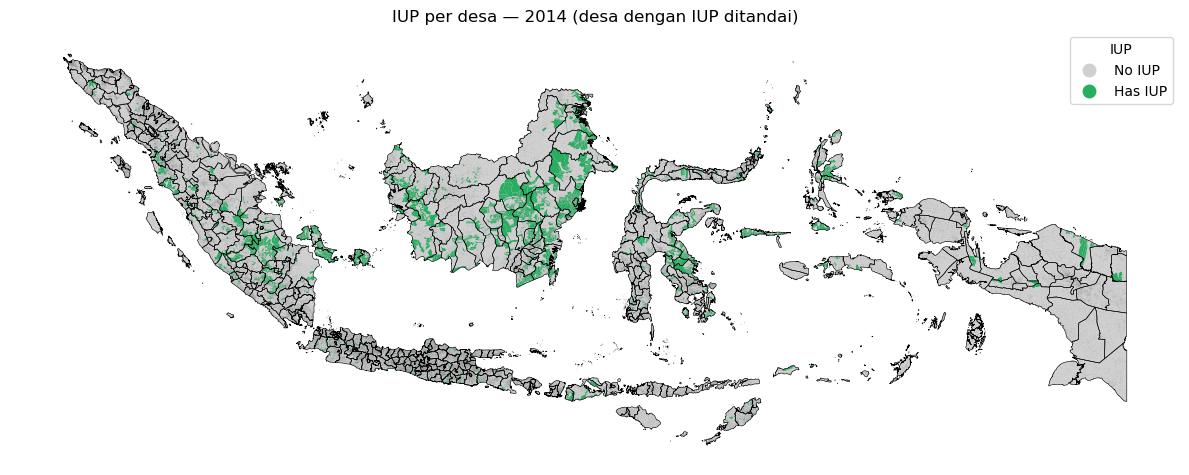

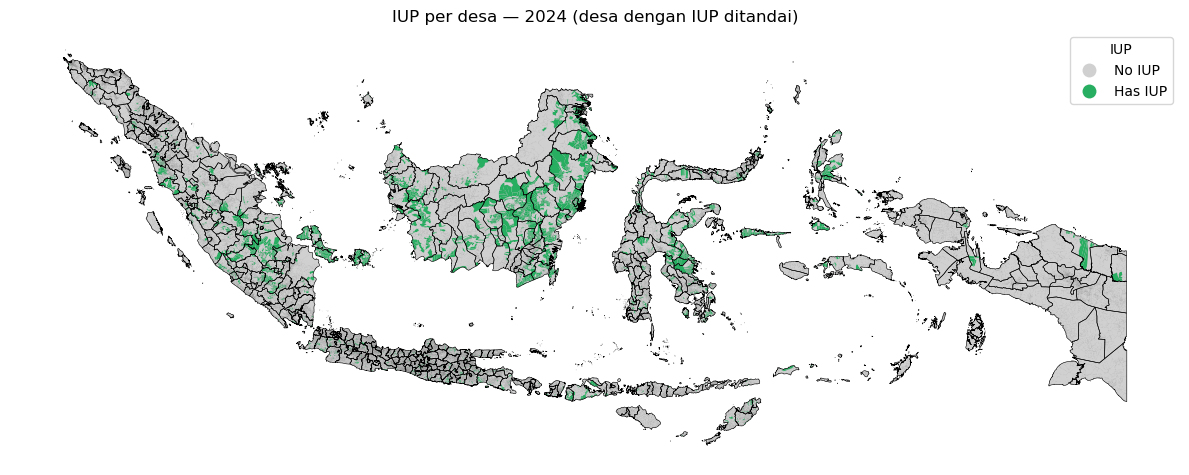

In [16]:
# Variation: IUP map — only highlight desa WITH IUP (others in light gray), 2014 and 2024
from matplotlib.colors import ListedColormap
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year].copy()
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    g["iup_plot"] = g["has_iup"].fillna(0).map({0: "No IUP", 1: "Has IUP"})
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = ListedColormap(["#d0d0d0", "#27ae60"])
    g.plot(column="iup_plot", categorical=True, legend=True, ax=ax,
           cmap=cmap, categories=["No IUP", "Has IUP"],
           linewidth=0.05, edgecolor="gray", legend_kwds={"title": "IUP"})
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"IUP per desa — {year} (desa dengan IUP ditandai)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

### Top provinces (desa dengan IUP) & welfare by IUP status

Bar chart: 15 provinsi dengan desa IUP terbanyak (2014 & 2024). Boxplot: distribusi skor Equity/Health (PCA) untuk desa dengan vs tanpa IUP — memberi nuansa apakah wilayah IUP sistematis berbeda dalam welfare.

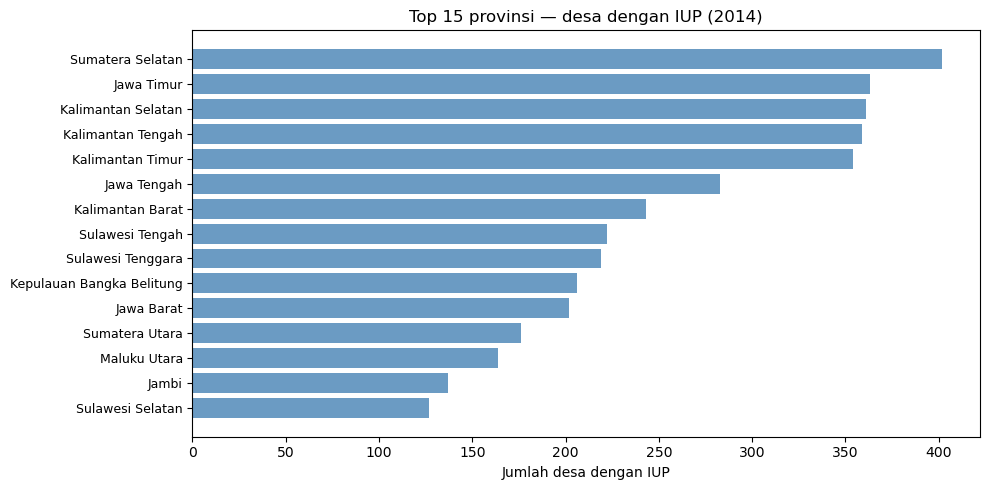

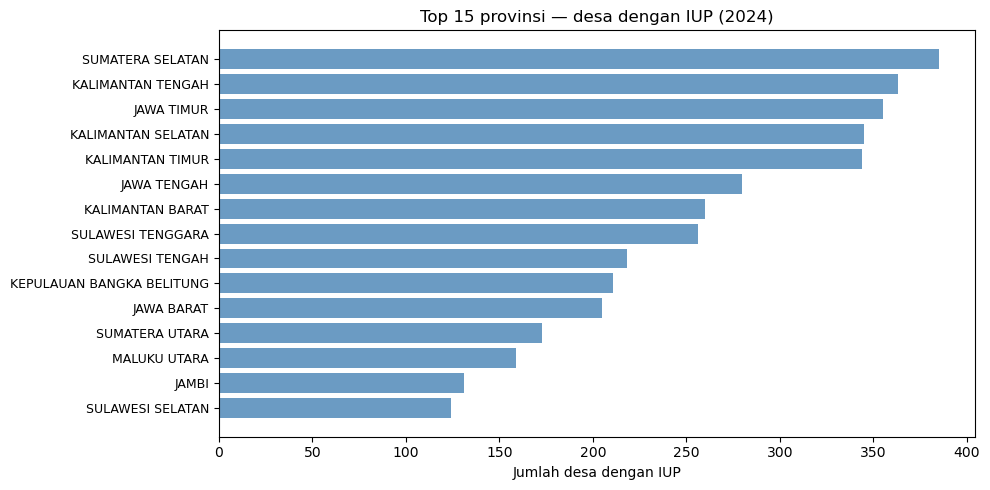

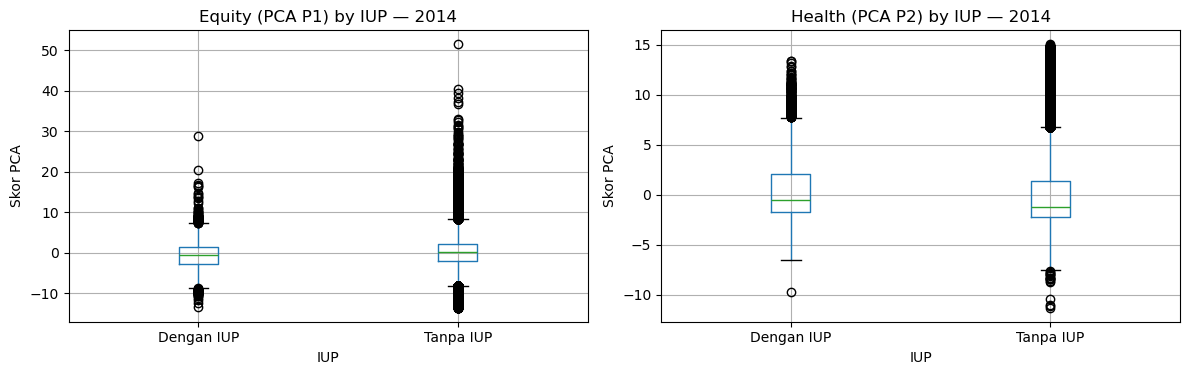

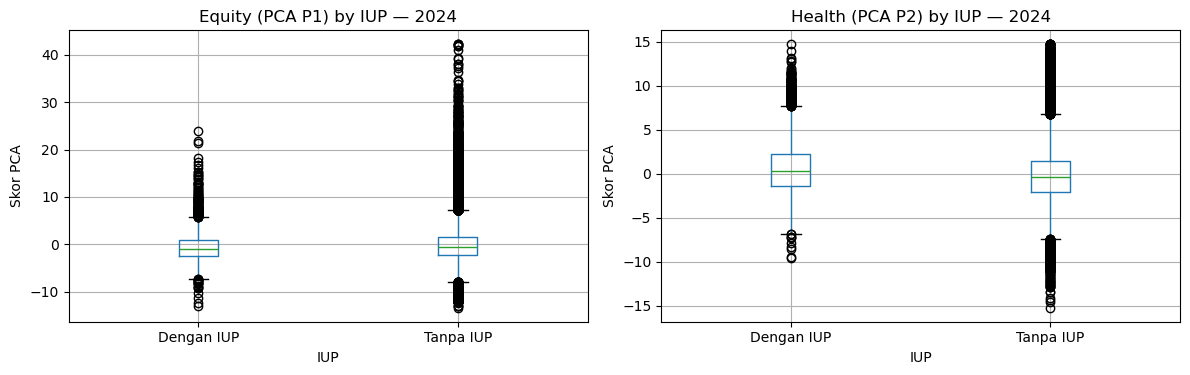

In [17]:
# Bar chart: top 15 provinces by number of desa dengan IUP (2014 and 2024)
for year in [2014, 2024]:
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    prov_col = "NAMA_PROV" if "NAMA_PROV" in g.columns else "ADM1_EN"
    if prov_col not in g.columns or "has_iup" not in g.columns:
        continue
    agg = g.groupby(prov_col).agg(n_desa=("has_iup", "count"), n_iup=("has_iup", "sum")).reset_index()
    agg = agg.sort_values("n_iup", ascending=False).head(15)
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.barh(range(len(agg)), agg["n_iup"], color="steelblue", alpha=0.8)
    ax.set_yticks(range(len(agg)))
    ax.set_yticklabels(agg[prov_col], fontsize=9)
    ax.set_xlabel("Jumlah desa dengan IUP")
    ax.set_title(f"Top 15 provinsi — desa dengan IUP ({year})")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Boxplot: welfare (PCA Equity & Health) by IUP status — 2014 and 2024
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year]
    if "has_iup" not in g.columns or "pca_P1_pc1" not in g.columns:
        continue
    df_bp = g[["has_iup", "pca_P1_pc1"]].copy()
    if "pca_P2_pc1" in g.columns:
        df_bp["pca_P2_pc1"] = g["pca_P2_pc1"]
    df_bp["IUP"] = df_bp["has_iup"].map({0: "Tanpa IUP", 1: "Dengan IUP"})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    df_bp.boxplot(column="pca_P1_pc1", by="IUP", ax=ax1)
    ax1.set_title(f"Equity (PCA P1) by IUP — {year}")
    ax1.set_ylabel("Skor PCA")
    if "pca_P2_pc1" in df_bp.columns:
        df_bp.boxplot(column="pca_P2_pc1", by="IUP", ax=ax2)
        ax2.set_title(f"Health (PCA P2) by IUP — {year}")
        ax2.set_ylabel("Skor PCA")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

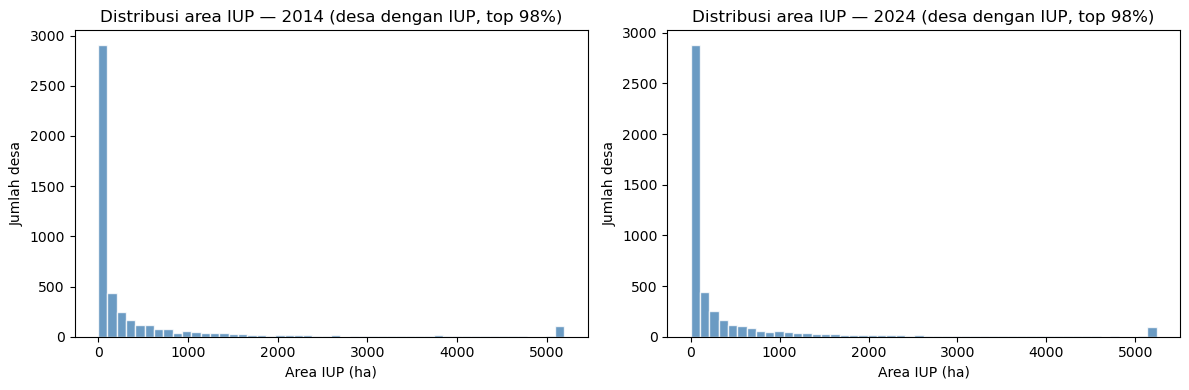

In [18]:
# Histogram: distribusi area IUP (ha) — desa dengan IUP saja, 2014 dan 2024
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, year in zip([ax1, ax2], [2014, 2024]):
    if year not in gdf_by_year:
        continue
    g = gdf_by_year[year]
    if "area_hectares_iup" not in g.columns or "has_iup" not in g.columns:
        continue
    wiup = g[g["has_iup"] == 1]["area_hectares_iup"].dropna()
    if len(wiup) == 0:
        continue
    ax.hist(wiup.clip(upper=wiup.quantile(0.98)), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Area IUP (ha)")
    ax.set_ylabel("Jumlah desa")
    ax.set_title(f"Distribusi area IUP — {year} (desa dengan IUP, top 98%)")
plt.tight_layout()
plt.show()

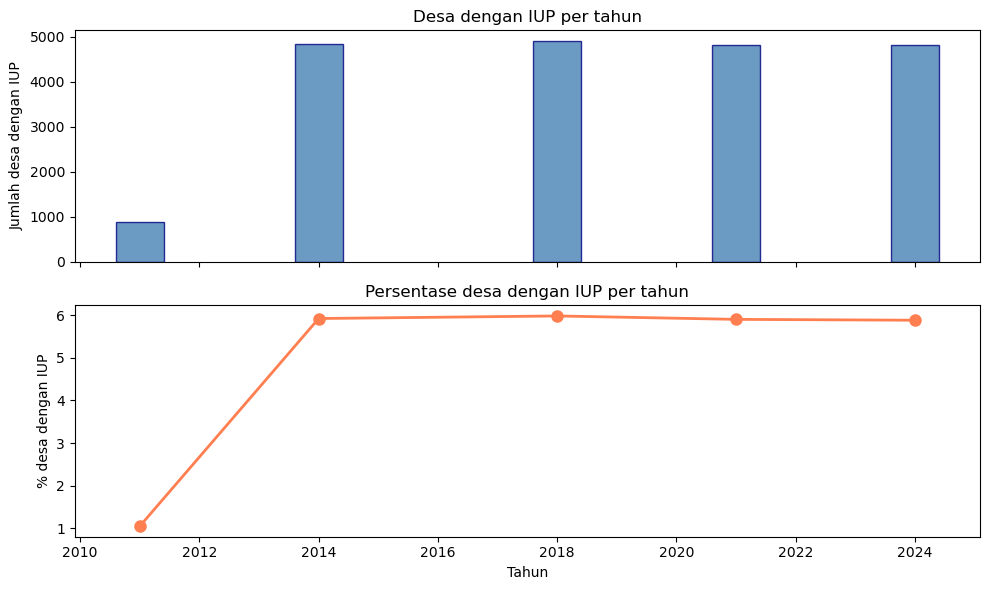

In [19]:
# Line chart: desa dengan IUP and % IUP over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df = df_desa_iup_by_year.sort_values("year")
ax1.bar(df["year"], df["desa_dengan_IUP"], color="steelblue", edgecolor="navy", alpha=0.8)
ax1.set_ylabel("Jumlah desa dengan IUP")
ax1.set_title("Desa dengan IUP per tahun")
ax2.plot(df["year"], df["pct_desa_IUP"], marker="o", color="coral", linewidth=2, markersize=8)
ax2.set_ylabel("% desa dengan IUP")
ax2.set_title("Persentase desa dengan IUP per tahun")
ax2.set_xlabel("Tahun")
plt.tight_layout()
plt.show()

In [20]:
# Table: distribusi area IUP (ha) — hanya desa dengan IUP, by year
area_rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year[y]
    if "area_hectares_iup" not in g.columns or "has_iup" not in g.columns:
        continue
    wiup = g[g["has_iup"] == 1]["area_hectares_iup"].dropna()
    if len(wiup) == 0:
        continue
    area_rows.append({
        "year": y,
        "n_desa_dengan_IUP": len(wiup),
        "area_ha_min": round(wiup.min(), 2),
        "area_ha_max": round(wiup.max(), 2),
        "area_ha_mean": round(wiup.mean(), 2),
        "area_ha_median": round(wiup.median(), 2),
    })
if area_rows:
    df_area_iup = pd.DataFrame(area_rows)
    print("Distribusi area_hectares_iup (desa dengan IUP):")
    display(df_area_iup)
else:
    print("Tidak ada data area_hectares_iup.")

Distribusi area_hectares_iup (desa dengan IUP):


,year,n_desa_dengan_IUP,area_ha_min,area_ha_max,area_ha_mean,area_ha_median
0,2011,880,0.0,42661.49,697.91,25.84
1,2014,4846,0.0,82509.38,579.52,44.62
2,2018,4902,0.0,82509.38,578.75,45.18
3,2021,4830,0.0,82509.38,587.31,44.58
4,2024,4813,0.0,82509.38,572.86,44.60


In [21]:
# Summary: all years — n_desa, desa dengan IUP, and PCA coverage in one table
summary_rows = []
for y in sorted(gdf_by_year.keys()):
    g = gdf_by_year.get(y)
    gpc = gdf_pca_by_year.get(y)
    r = {"year": y}
    if g is not None:
        r["n_desa"] = len(g)
        r["desa_dengan_IUP"] = int(g["has_iup"].fillna(0).sum()) if "has_iup" in g.columns else None
        r["pct_IUP"] = round(100 * r["desa_dengan_IUP"] / r["n_desa"], 2) if r["desa_dengan_IUP"] is not None else None
    if gpc is not None:
        for col in ["pca_P1_pc1", "pca_P2_pc1"]:
            if col in gpc.columns:
                r[f"n_valid_{col}"] = gpc[col].notna().sum()
    summary_rows.append(r)
df_summary_all = pd.DataFrame(summary_rows)
df_summary_all

,year,n_desa,desa_dengan_IUP,pct_IUP,n_valid_pca_P1_pc1,n_valid_pca_P2_pc1
0,2011,83862,880,1.05,18731,18731
1,2014,81912,4846,5.92,79681,79681
2,2018,81912,4902,5.98,80822,80822
3,2021,81912,4830,5.90,80350,80350
4,2024,81912,4813,5.88,77123,77123


### Smelter — descriptive stats

Ringkasan jumlah desa terdampak smelter per tahun (Regimen 1 & 2), per provinsi, dan daftar lokasi dari **Data Smelter Indonesia.xlsx**. Ditambah: overlap IUP–smelter dan rata-rata welfare (Equity/Health PCA) menurut status smelter. *(Panel dan daftar smelter di-load di cell berikutnya.)*

In [22]:
# Load smelter panel and list (required for smelter stats below and for Section 5 maps)
PANEL_SMELTER_PATH = DATA_BERSIH / "panel_PCA_with_smelter.csv"
SMELTER_XLSX = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Data Smelter Indonesia.xlsx")
panel_smelter = None
if PANEL_SMELTER_PATH.exists():
    panel_smelter = pd.read_csv(PANEL_SMELTER_PATH)
    print("Panel dengan smelter:", panel_smelter.shape, "| reg1:", panel_smelter["smelter_reg1"].sum(), "| reg2:", panel_smelter["smelter_reg2"].sum())
else:
    print("File panel_PCA_with_smelter.csv tidak ditemukan; jalankan cleaning2 dulu.")
smelter_df = None
if SMELTER_XLSX.exists():
    smelter_df = pd.read_excel(SMELTER_XLSX, sheet_name="Sheet1")
    print("Jumlah baris smelter:", len(smelter_df))

Panel dengan smelter: (411510, 11) | reg1: 156 | reg2: 594
Jumlah baris smelter: 23


Jumlah desa dengan smelter per tahun:


,year,n_desa,n_smelter_reg1,n_smelter_reg2,pct_reg1,pct_reg2
0,2011,83862,1,13,0.00,0.02
1,2014,81912,39,146,0.05,0.18
2,2018,81912,39,146,0.05,0.18
3,2021,81912,39,146,0.05,0.18
4,2024,81912,38,143,0.05,0.17


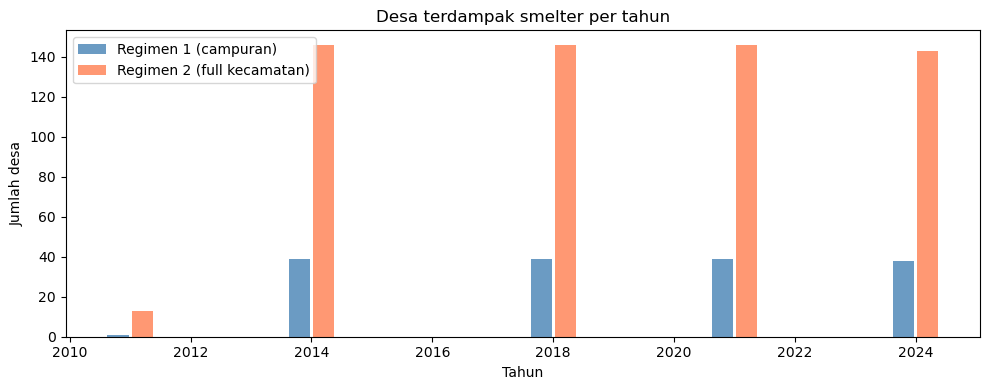

In [23]:
# Smelter descriptive stats — desa dengan smelter by year (Regimen 1 & 2)
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    smelter_by_year = panel_smelter.groupby("year").agg(
        n_desa=("smelter_reg1", "count"),
        n_smelter_reg1=("smelter_reg1", "sum"),
        n_smelter_reg2=("smelter_reg2", "sum"),
    ).reset_index()
    smelter_by_year["pct_reg1"] = (100 * smelter_by_year["n_smelter_reg1"] / smelter_by_year["n_desa"]).round(2)
    smelter_by_year["pct_reg2"] = (100 * smelter_by_year["n_smelter_reg2"] / smelter_by_year["n_desa"]).round(2)
    print("Jumlah desa dengan smelter per tahun:")
    display(smelter_by_year)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    x = smelter_by_year["year"]
    ax.bar(x - 0.2, smelter_by_year["n_smelter_reg1"], width=0.35, label="Regimen 1 (campuran)", color="steelblue", alpha=0.8)
    ax.bar(x + 0.2, smelter_by_year["n_smelter_reg2"], width=0.35, label="Regimen 2 (full kecamatan)", color="coral", alpha=0.8)
    ax.set_ylabel("Jumlah desa")
    ax.set_xlabel("Tahun")
    ax.set_title("Desa terdampak smelter per tahun")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Panel smelter tidak ada; jalankan cell load panel di atas.")

In [24]:
# Smelter by province (year 2024) and list of smelter locations
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    prov_col = "NAMA_PROV" if "NAMA_PROV" in panel_smelter.columns else "ADM1_EN"
    if prov_col in panel_smelter.columns:
        sub = panel_smelter[panel_smelter["year"] == 2024]
        agg = sub.groupby(prov_col).agg(n_desa=("smelter_reg1", "count"), n_smelter_r1=("smelter_reg1", "sum"), n_smelter_r2=("smelter_reg2", "sum")).reset_index()
        agg = agg[agg["n_smelter_r1"] > 0].sort_values("n_smelter_r1", ascending=False)
        print("Provinsi dengan desa terdampak smelter (2024) — Regimen 1 & 2:")
        display(agg.head(15))
if smelter_df is not None and len(smelter_df) > 0:
    print("\nDaftar lokasi smelter (Data Smelter Indonesia.xlsx) — 15 baris pertama:")
    display(smelter_df.head(15))

Provinsi dengan desa terdampak smelter (2024) — Regimen 1 & 2:


,NAMA_PROV,n_desa,n_smelter_r1,n_smelter_r2
28,SULAWESI TENGAH,1984,14,34
20,MALUKU UTARA,1176,10,24
29,SULAWESI TENGGARA,2271,9,9
11,KALIMANTAN BARAT,2132,2,26
13,KALIMANTAN TENGAH,1570,1,18
17,KEPULAUAN RIAU,378,1,4
19,MALUKU,1227,1,6



Daftar lokasi smelter (Data Smelter Indonesia.xlsx) — 15 baris pertama:


,no,perusahaan,mineral,tahun_operasi,desa,kecamatan,kabupaten,provinsi
0,1,PT Aneka Tambang Tbk (Pomalaa),Nikel,1976,NaN,Pomala,Kolaka,Sulawesi Tenggara
1,2,PT Vale Indonesia Tbk (Sorowako),Nikel,1978,Sorowako,Nuha,Luwu Timur,Sulawesi Selatan
2,3,PT Weda Bay Nickel,Nikel,2020,Lililef Sawai,Weda Tengah,Halmahera Tengah,Maluku Utara
3,4,PT Halmahera Persada Lygend,Nikel,2021,Kawasi,Obi,Halmahera Selatan,Maluku Utara
4,5,PT Gunbuster Nickel Industry,Nikel,2019,Bungintimbe,Petasia Timur,Morowali Utara,Sulawesi Tengah
5,6,PT Virtue Dragon Nickel Industry,Nikel,2015,NaN,Bondoala,Konawe,Sulawesi Tenggara
6,7,PT Obsidian Stainless Steel,Nikel,2017,NaN,Bondoala,Konawe,Sulawesi Tenggara
7,8,PT Huadi Nickel-Alloy Indonesia,Nikel,2019,Papan Loe,Pa'jukukang,Bantaeng,Sulawesi Selatan
8,9,PT Sulawesi Mining Investment,Nikel,2015,NaN,Bahodopi,Morowali,Sulawesi Tengah
9,10,PT Indonesia Guang Ching Nickel,Nikel,2016,NaN,Bahodopi,Morowali,Sulawesi Tengah


In [25]:
# Overlap IUP–smelter: desa that have both IUP and smelter (Regimen 1 & 2) by year
# Mean welfare (PCA) by smelter status (Regimen 1) by year
if panel_smelter is not None and "smelter_reg1" in panel_smelter.columns:
    id_panel = "id_desa" if "id_desa" in panel_smelter.columns else "id_desa_numeric"
    overlap_rows = []
    for y in sorted(panel_smelter["year"].unique()):
        sub = panel_smelter[panel_smelter["year"] == y]
        n = len(sub)
        n_r1 = sub["smelter_reg1"].sum()
        n_r2 = sub["smelter_reg2"].sum()
        if "has_iup" in sub.columns:
            n_iup = sub["has_iup"].fillna(0).sum()
            n_both_r1 = ((sub["smelter_reg1"] == 1) & (sub["has_iup"] == 1)).sum()
            n_both_r2 = ((sub["smelter_reg2"] == 1) & (sub["has_iup"] == 1)).sum()
            overlap_rows.append({"year": y, "n_desa": n, "n_IUP": n_iup, "n_smelter_r1": n_r1, "n_smelter_r2": n_r2,
                                "n_IUP_dan_smelter_r1": n_both_r1, "n_IUP_dan_smelter_r2": n_both_r2})
        else:
            overlap_rows.append({"year": y, "n_desa": n, "n_smelter_r1": n_r1, "n_smelter_r2": n_r2})
    if overlap_rows:
        df_overlap = pd.DataFrame(overlap_rows)
        print("Overlap IUP & smelter per tahun (desa yang punya IUP dan terdampak smelter):")
        display(df_overlap)

    # Mean welfare (Equity & Health PCA) by smelter status (Regimen 1) by year
    if "pca_P1_pc1" in panel_smelter.columns:
        welf_rows = []
        for y in sorted(panel_smelter["year"].unique()):
            sub = panel_smelter[panel_smelter["year"] == y]
            for reg in [0, 1]:
                s = sub[sub["smelter_reg1"] == reg]
                if len(s) == 0:
                    continue
                r = {"year": y, "smelter_reg1": "Ya" if reg == 1 else "Tidak", "n_desa": len(s)}
                if "pca_P1_pc1" in s.columns:
                    r["mean_Equity_P1"] = round(s["pca_P1_pc1"].mean(), 4)
                    r["std_Equity_P1"] = round(s["pca_P1_pc1"].std(), 4)
                if "pca_P2_pc1" in s.columns:
                    r["mean_Health_P2"] = round(s["pca_P2_pc1"].mean(), 4)
                    r["std_Health_P2"] = round(s["pca_P2_pc1"].std(), 4)
                welf_rows.append(r)
        if welf_rows:
            df_welf_smelter = pd.DataFrame(welf_rows)
            print("\nRata-rata welfare (PCA) menurut status smelter Regimen 1 per tahun:")
            display(df_welf_smelter)
else:
    print("Panel smelter tidak ada; jalankan cell load panel di atas.")

Overlap IUP & smelter per tahun (desa yang punya IUP dan terdampak smelter):


,year,n_desa,n_IUP,n_smelter_r1,n_smelter_r2,n_IUP_dan_smelter_r1,n_IUP_dan_smelter_r2
0,2011,83862,880,1,13,1,10
1,2014,81912,4846,39,146,20,61
2,2018,81912,4902,39,146,19,60
3,2021,81912,4830,39,146,20,63
4,2024,81912,4813,38,143,20,62



Rata-rata welfare (PCA) menurut status smelter Regimen 1 per tahun:


,year,smelter_reg1,n_desa,mean_Equity_P1,std_Equity_P1,mean_Health_P2,std_Health_P2
0,2011,Tidak,83861,-0.0013,3.8680,-0.0013,2.7024
1,2011,Ya,1,24.4573,NaN,24.3282,NaN
2,2014,Tidak,81873,0.0012,3.9715,-0.0013,3.6020
3,2014,Ya,39,-2.6061,2.4856,2.7374,3.9425
4,2018,Tidak,81873,-0.0013,4.4588,-0.0012,3.5635
5,2018,Ya,39,2.7922,3.3513,2.6033,3.0389
6,2021,Tidak,81873,0.0010,3.7211,-0.0018,4.6462
7,2021,Ya,39,-2.1072,2.1345,3.8067,3.5077
8,2024,Tidak,81874,0.0010,3.7222,-0.0011,3.2640
9,2024,Ya,38,-2.0279,2.2696,2.1627,3.7695


## 5. Peta intervensi smelter

Data: **Data Smelter Indonesia.xlsx** (kecamatan-level; semua desa di kecamatan terdampak).  
Panel dengan flag: **panel_PCA_with_smelter.csv** dari cleaning2 (smelter_reg1 = campuran, smelter_reg2 = full kecamatan).  
Peta: desa dengan intervensi smelter (Regimen 1 & 2) untuk 2014 dan 2024.

In [26]:
# Load smelter panel (from cleaning2) for mapping. (Also loaded in Section 4; run this if you run Section 5 only.)
PANEL_SMELTER_PATH = DATA_BERSIH / "panel_PCA_with_smelter.csv"
SMELTER_XLSX = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Data Smelter Indonesia.xlsx")
panel_smelter = None
if PANEL_SMELTER_PATH.exists():
    panel_smelter = pd.read_csv(PANEL_SMELTER_PATH)
    print("Panel dengan smelter:", panel_smelter.shape, "| jumlah reg1:", panel_smelter["smelter_reg1"].sum(), "| jumlah reg2:", panel_smelter["smelter_reg2"].sum())
else:
    print("File panel_PCA_with_smelter.csv tidak ditemukan; jalankan cleaning2 dulu.")
smelter_df = None
if SMELTER_XLSX.exists():
    smelter_df = pd.read_excel(SMELTER_XLSX, sheet_name="Sheet1")
    print("Jumlah baris smelter:", len(smelter_df))

Panel dengan smelter: (411510, 11) | jumlah reg1: 156 | jumlah reg2: 594
Jumlah baris smelter: 23


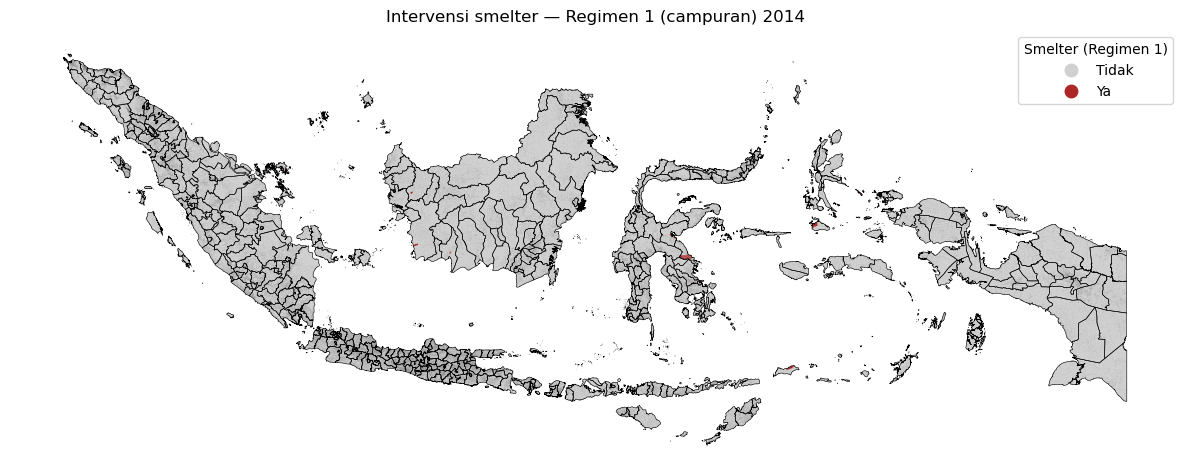

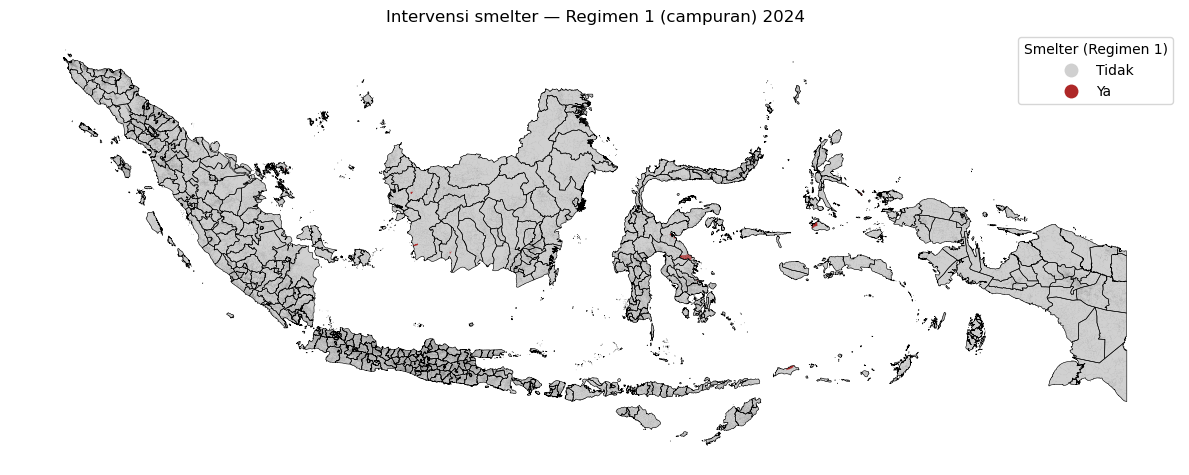

In [27]:
# Smelter map — Regimen 1 (campuran: desa or whole kecamatan) 2014 and 2024
id_panel = "id_desa" if "id_desa" in panel_smelter.columns else "id_desa_numeric"
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year].copy()
    if not hasattr(g, "geometry") or g.geometry is None:
        continue
    gid = "id_desa_numeric" if "id_desa_numeric" in g.columns else ("id_desa" if "id_desa" in g.columns else "ID_DESA")
    sub = panel_smelter.loc[panel_smelter["year"] == year, [id_panel, "smelter_reg1"]].drop_duplicates(id_panel)
    g = g.merge(sub, left_on=gid, right_on=id_panel, how="left")
    g["smelter_reg1"] = g["smelter_reg1"].fillna(0).astype(int)
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = ListedColormap(["#d0d0d0", "#ae2727"])
    g.plot(column="smelter_reg1", categorical=True, legend=True, ax=ax, cmap=cmap, categories=[0, 1],
            legend_kwds={"title": "Smelter (Regimen 1)", "labels": ["Tidak", "Ya"]}, linewidth=0.05, edgecolor="gray")
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Intervensi smelter — Regimen 1 (campuran) {year}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


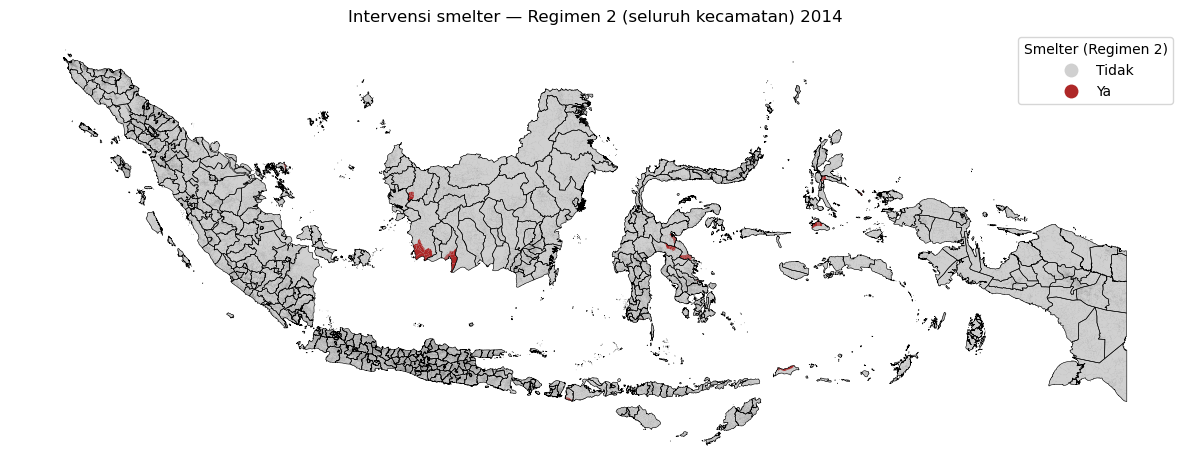

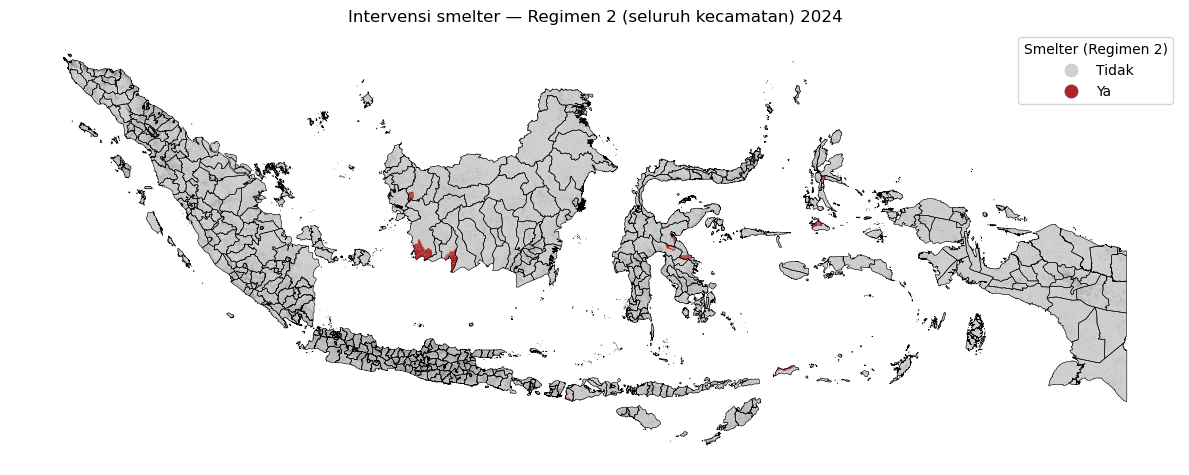

In [28]:
# Smelter map — Regimen 2 (full kecamatan) 2014 and 2024
id_panel = "id_desa" if "id_desa" in panel_smelter.columns else "id_desa_numeric"
for year in [2014, 2024]:
    if year not in gdf_pca_by_year:
        continue
    g = gdf_pca_by_year[year].copy()
    if not hasattr(g, "geometry") or g.geometry is None:
        continue
    gid = "id_desa_numeric" if "id_desa_numeric" in g.columns else ("id_desa" if "id_desa" in g.columns else "ID_DESA")
    sub = panel_smelter.loc[panel_smelter["year"] == year, [id_panel, "smelter_reg2"]].drop_duplicates(id_panel)
    g = g.merge(sub, left_on=gid, right_on=id_panel, how="left")
    g["smelter_reg2"] = g["smelter_reg2"].fillna(0).astype(int)
    if g.crs is None:
        g.set_crs(4326, inplace=True)
    by_col = "ADM2_PCODE" if "ADM2_PCODE" in g.columns else "NAMA_KAB"
    admin = g.dissolve(by=by_col, aggfunc="first").reset_index()
    admin = gpd.GeoDataFrame(admin, geometry=admin.geometry, crs=g.crs)
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    cmap = ListedColormap(["#d0d0d0", "#ae2727"])
    g.plot(column="smelter_reg2", categorical=True, legend=True, ax=ax, cmap=cmap, categories=[0, 1],
            legend_kwds={"title": "Smelter (Regimen 2)", "labels": ["Tidak", "Ya"]}, linewidth=0.05, edgecolor="gray")
    admin.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Intervensi smelter — Regimen 2 (seluruh kecamatan) {year}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()